module://matplotlib_inline.backend_inline


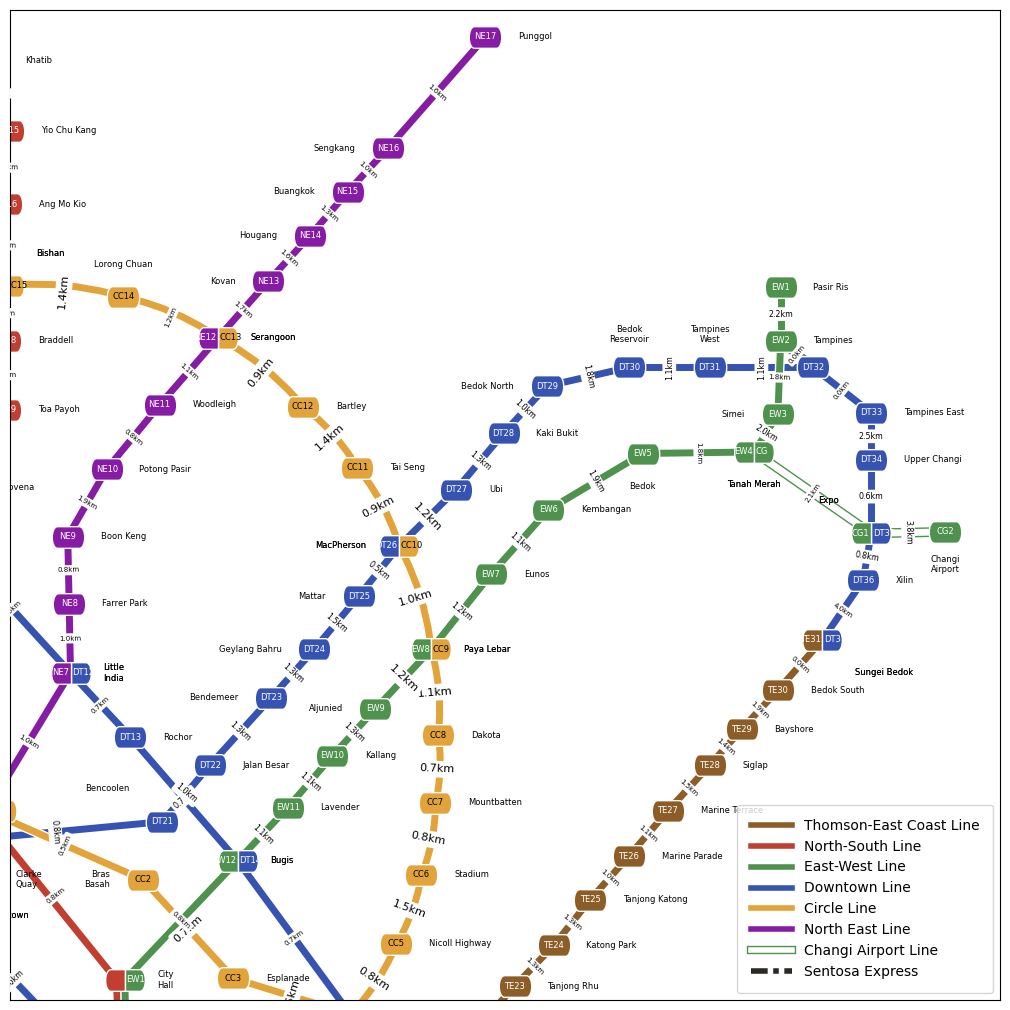

In [5]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SPREAD = 100
user_input = 30 #input("Input size in inches (default is 13):\n")
FIGSIZE = 10 #int(user_input) if user_input.strip() else 13
DISTANCE_VISIBLE = True #True if input("Do you want to see distances between stations? y/n\n") == "y" else False
IS_KM = True #True if input("Do you want to see kilometers or meters? km/m\n") == "km" else False
NO_LINES = 8 #input("Input number of lines to display (Min 5, Max 8):\n")
SHOW_CODES = True


def run():
    global data

    data_loader = StationDataLoader(data)
    lines = data_loader.load_lines()
    stations = data_loader.load_stations()

    plotter = StationMapPlotter(stations, lines)
    plotter.draw_nodes_and_edges()
    plotter.draw_labels()
    plotter.draw_legend()

    plotter.show_map()

class StationDataLoader:
    def __init__(self, data: str):
        self.data = data
        self.__parsed: dict = eval(self.data
                      .replace('null', 'None')
                      .replace('true', 'True')
                      .replace('false', 'False'))
        self.__lines: dict[int, "Line"] = {}
        self.__stations: dict[int, "Station"] = {}
    
    def load_stations(self) -> list["Station"]:
        self.__load_stations()
        self.__load_station_lines()
    
        return list(self.__stations.values())
    
    def load_lines(self) -> list["Line"]:
        count = 0
        for line in self.__parsed["lines"].values():
            self.__lines[line["id"]] = (Line(**line))
            count += 1
            if count >= int(NO_LINES): break
            
        return list(self.__lines.values())
        
    def __load_stations(self):
        for station in self.__parsed["stations"].values():
            self.__stations[station["id"]] = \
                Station(**{k: station[k] for k in [
                    "id", 
                    "station_name", 
                    "x", 
                    "y",
                    "lon", 
                    "lat", 
                    "name_wrap",
                    "name_direction"]})

    def __load_station_lines(self):
        station_lines: dict[int, "StationLine"] = {}
        for station_line in self.__parsed["station_lines"].values():
            toAdd = StationLine(**{k: station_line[k] for k in ["id", "station_code"]})
            toAdd.line = self.__lines[station_line["line_id"]]

            join = station_line["join"]
            if join is not None:
                toAdd.join = StationLineJoin(join["position"], join["offset"], join["separate"], join["is_triplet"])

            stationRef = self.__stations[station_line["station_id"]]
            stationRef.station_lines.append(toAdd)
            toAdd.station = stationRef

            station_lines[toAdd.id] = toAdd
            
        for station_line in station_lines.values():
            station_line.connections = self.__create_connections(station_lines, 
                                                                 self.__parsed["station_lines"][str(station_line.id)]["connections"])
        return station_lines

    def __create_connections(self, station_lines: dict[int, "StationLine"], connections: dict):
        connections_list: list["Connection"] = []
        for connection in connections:
            try:
                toAdd = Connection(station_lines[connection["next_station_line_id"]], 
                                self.__lines[connection["line_id"]], 
                                connection["connection_style"])
                connections_list.append(toAdd)
            except:
                pass
            
        return connections_list
      
class StationMapPlotter:
    SC_MIN_FONT_SIZE = 6
    SC_MAX_FONT_SIZE = 7
    SD_MIN_FONT_SIZE = 5
    SD_MAX_FONT_SIZE = 8
    
    def __init__(self, stations: list["Station"], lines:list["Line"]):
        self.stations = stations
        self.lines = lines
        self.__graph = nx.Graph()
        self.__station_name_labels: list[plt.Text] = []
        self.__station_code_labels: list[plt.Text] = []
        self.__station_distance_labels: list[plt.Text] = []
        self.__pos = self.__generate_pos()
        self.__fig = plt.figure(figsize=(FIGSIZE, FIGSIZE))
        
    def show_map(self):
        plt.axis('equal')
        
        plt.subplots_adjust(top=0.995, bottom=0.005, left=0.005, right=0.995)
        ax = plt.gca()
        ax.set_xlim(113.91, 53.47)
        ax.set_ylim(-79.62, -19.18)
        ax.invert_xaxis()
        ax.callbacks.connect('xlim_changed', self.__on_zoom)

        print(plt.get_backend())
        
        plt.show()

    def draw_nodes_and_edges(self):
        for station in self.stations:
            for station_line in station.station_lines:
                self.__draw_node(station, station_line)
                self.__draw_edges_for_node(station, station_line)

    def draw_labels(self):
        for node_key, node_attributes in self.__graph.nodes(data=True):
            x, y = self.__pos[node_key]
            station_code:str = node_key
            station: "Station" = node_attributes["s"]
            station_name = station.station_name
            station_line: "StationLine" = node_attributes["sl"]
            if station_line.join is None or not station_line.join.separate:
                if SHOW_CODES:
                    self.__draw_station_code(x, y, station_code, station_line)
                self.__draw_station_name(x, y, station_name, station)

    def draw_legend(self):
        ax = plt.gca()
        HandlerTuple = plt.matplotlib.legend_handler.HandlerTuple
        handles = []
        plotlines = []
        for line in self.lines:
            plotlines.append(line.name)
            border = plt.Line2D([0], [0], color='white', linewidth=6)
            plottedLine = plt.Line2D([0], [0], color=line.colour, linewidth=4, label=line.name)
            if(line.code == "STE"): #sentosa
                border.set_linestyle((0, (3, 1, 1, 1)))
                plottedLine.set_linestyle((0, (3, 1, 1, 1)))
            if(line.code == "CG"): #changi airport
                border.set_color(line.colour)
                plottedLine.set_color("white")
                
            handles.append((border, plottedLine))

        ax.legend(
            handles=handles,
            labels=plotlines,
            handler_map={tuple: HandlerTuple(ndivide=1, pad=0)},
            loc='lower right',
            framealpha=0.8,
            handlelength=3,
            borderpad=1
        )

    def __generate_pos(self):
        pos = {}
        for station in self.stations:
            for station_line in station.station_lines:
                x = station.x * SPREAD
                y = station.y * -SPREAD
                pos[station_line.station_code] = (x, y)
                if station_line.join is not None and station_line.join.separate:
                    
                    x = (station.x - (station_line.join.offset - station.x)) * SPREAD
                    pos[station_line.station_code + "JOIN"] = (x, y) #offsets here
        return pos

    def __draw_node(self, station: "Station", station_line: "StationLine"):
        self.__graph.add_node(station_line.station_code, s=station, sl=station_line)
        colour = station_line.line.colour
        nodes = nx.draw_networkx_nodes(self.__graph, 
                                            self.__pos,
                                            nodelist=[station_line.station_code],
                                            node_color=colour,
                                            edgecolors="white",
                                            linewidths=1,
                                            alpha=1 if station_line.station_code != "STE1" else 0
                                            )
        custom_path = self.__get_custom_shape(station_line.join)
        nodes.set_paths([custom_path])
        if station_line.join is not None and station_line.join.separate:
            join_code = station_line.station_code + "JOIN"
            self.__graph.add_node(join_code, s=station, sl=station_line)
            nx.draw_networkx_nodes(self.__graph, self.__pos, nodelist=[join_code], alpha=0)

    def __draw_edges_for_node(self, station: "Station", station_line: "StationLine"):
        for connection in station_line.connections:
            conStyle = connection.connection_style
            colour = connection.line.colour
            next = connection.next_station
            
            code1 = station_line.station_code
            code2 = next.station_code
            if station_line.join is not None and station_line.join.separate: 
                code1 = code1 + "JOIN"
                code2 = code2 if next.join is None else code2 + "JOIN"
            self.__graph.add_edge(code1, code2)
                    
            edge = [(code1, code2)]
            if conStyle == "double":
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=7, edge_color=colour)
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=5, edge_color="white")
            elif conStyle == "special":
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=5, edge_color="white")
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=7, edge_color="gray")
            elif conStyle == "dashdot": #dashdot doesn't look very good so we customise the size and cadence ourselves
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=7, edge_color="white", style=(0, (5, 2, 1, 2)))
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=5, edge_color=colour, style=(0, (5, 2, 1, 2)))
            elif (code1.startswith("CC") or code1.startswith("CE")) and \
                (code1 != "CC1" and code1 != "CC2" and code1 != "CC3"):
                nx.draw_networkx_edges(self.__graph, self.__pos, arrows=True, edgelist=edge, width=7, edge_color="white", style=conStyle, connectionstyle="arc3,rad=0.1")
                nx.draw_networkx_edges(self.__graph, self.__pos, arrows=True, edgelist=edge, width=5, edge_color=colour, style=conStyle, connectionstyle="arc3,rad=0.1")
            else:
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=7, edge_color="white", style=conStyle)
                nx.draw_networkx_edges(self.__graph, self.__pos, edgelist=edge, width=5, edge_color=colour, style=conStyle)
            if DISTANCE_VISIBLE:
                distance = station.calculate_distance(next.station)
                self.__draw_edge_label(station_line, connection, distance)
        
    def __draw_station_name(self, x, y, station_name: str, station: "Station"):
        font_size = self.__get_appropriate_font_size()
        clean = station_name if not station.name_wrap else station_name.replace(" ", "\n")
        name = plt.text(x, y, clean, fontsize=font_size, ha="center", va="center", clip_on=True)
        if len(station.name_direction) == 0:
            name.set_visible(False)
        for direction in station.name_direction:
            offset = 2
            if direction == "left":
                name.set_horizontalalignment("right")
                x = x - offset
            if direction == "right":
                name.set_horizontalalignment("left")
                x = x + offset
            if direction == "top":
                y = y + offset
            if direction == "bottom":
                y = y - offset
            name.set_x(x)
            name.set_y(y)
        self.__station_name_labels.append(name)

    def __draw_station_code(self, x, y, station_code:str, station_line: "StationLine"):
        font_size = self.__get_appropriate_font_size(minSize=self.SC_MIN_FONT_SIZE,
                                                     maxSize=self.SC_MAX_FONT_SIZE)
        code = plt.text(x, y, station_code, fontsize=font_size, ha="center", va="center", clip_on=True)
        if station_line.join is not None:
            join = station_line.join
            #there's something funky with ha
            position = "left" if join.position == "right" else "center" if join.position == "middle" else "right" 
            code.set_horizontalalignment(position)
            if position == "left":
                code.set_x(x + 0.1)
            elif position == "right":
                code.set_x(x - 0.1)
            else:
                code.set_x(x + 0.15)
                
        if station_line.line.colour_is_dark():
            code.set_color("white")
        else:
            code.set_color("black")
            
        if station_code.startswith("STE"): #Sentosa doesn't have a code in MRT map
            code.set_text(None)
            
        self.__station_code_labels.append(code)

    def __draw_edge_label(self, station_line: "StationLine", connection: "Connection", distance: float):
        x1, y1 = self.__pos[station_line.station_code]
        x2, y2 = self.__pos[connection.next_station.station_code]
        
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2 #halfway between one and the other
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) + 90 #perpendicular
        
        #angle correction
        if angle > 90: angle -= 180
        if angle < -90: angle += 180

        sign = "km" if IS_KM else "m"
        font_size = self.__get_appropriate_font_size(minSize=self.SD_MIN_FONT_SIZE,
                                                     maxSize=self.SD_MAX_FONT_SIZE)
        distance_label = plt.text(mid_x, 
                mid_y, 
                f"{distance:.1f}{sign}", 
                fontsize=font_size, 
                ha='center', 
                va='center', 
                rotation=angle,
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=1),
                clip_on=True)
        
        self.__station_distance_labels.append(distance_label)
    
    def __get_appropriate_font_size(self, minSize = 6, maxSize = 16):
        ax = plt.gca()
        x_values = [x for x, y in self.__pos.values()]
        full_range = max(x_values) - min(x_values)

        xlim = ax.get_xlim()
        current_range = abs(xlim[1] - xlim[0])

        ratio = full_range / current_range
        font_size = max(minSize, min(maxSize, minSize * ratio))

        return font_size
    
    def __get_custom_shape(self, join: "StationLineJoin"):
        Path = plt.matplotlib.path.Path
        
        s = 0.45 # normal scale (y when split)
        c = 0.3 # bulge of the curve
        x = 0.6 # bigger width for split paths
        m = 0.4  # half-width of middle section
        
        side = None
        is_triplet = False
        if join is not None:
           side = join.position
           is_triplet = join.is_triplet
            
        if side == 'left':
            right_edge = -m if is_triplet else 0
            x = x if not is_triplet else x + 0.4
            verts = [
                (-x, -s), (right_edge, -s),
                (right_edge, s), (-x, s),
                (-x-c, s), (-x-c, -s), (-x, -s),
                (-x, -s)
            ]
            codes = [
                Path.MOVETO, Path.LINETO,
                Path.LINETO, Path.LINETO,
                Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.CLOSEPOLY,
            ]
        elif side == 'right':
            left_edge = m if is_triplet else 0
            x = x if not is_triplet else x + 0.4
            verts = [
                (left_edge, -s), (x, -s),
                (x+c, -s), (x+c, s), (x, s),
                (left_edge, s), (left_edge, -s),
                (left_edge, -s)
            ]
            codes = [
                Path.MOVETO, Path.LINETO,
                Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.LINETO, Path.LINETO,
                Path.CLOSEPOLY,
            ]
        elif side == "middle":
            verts = [
                (-m, -s), (m, -s),
                (m, s), (-m, s),
                (-m, -s)
            ]
            codes = [
                Path.MOVETO, Path.LINETO,
                Path.LINETO, Path.LINETO,
                Path.CLOSEPOLY
            ]
        else:  # full
            verts = [
                (-s, -s), (s, -s),
                (s+c, -s), (s+c, s), (s, s),
                (-s, s),
                (-s-c, s), (-s-c, -s), (-s, -s),
                (-s, -s),
            ]
            codes = [
                Path.MOVETO, Path.LINETO,
                Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.LINETO,
                Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.CLOSEPOLY,
            ]

        return Path(verts, codes)

    def __on_zoom(self, ax: plt.matplotlib.axes.Axes):
        font_size = self.__get_appropriate_font_size()
        for label in self.__station_name_labels:
            label.set_fontsize(font_size)
            
        code_font_size = self.__get_appropriate_font_size(minSize=self.SC_MIN_FONT_SIZE, 
                                                          maxSize=self.SC_MAX_FONT_SIZE)
        for code in self.__station_code_labels:
            code.set_fontsize(code_font_size)

        distance_font_size = self.__get_appropriate_font_size(minSize=self.SD_MIN_FONT_SIZE,
                                                              maxSize=self.SD_MAX_FONT_SIZE)
        for distance in self.__station_distance_labels:
            distance.set_fontsize(distance_font_size)
        
        ax.figure.canvas.draw_idle()
        
class Coord:
    def __init__(self, lon: float, lat: float):
        self.lon = lon 
        self.lat = lat
    
    def lon_to_radian(self):
        return self.lon * np.pi/180
    def lat_to_radian(self):
        return self.lat * np.pi/180
    
class Line:
    def __init__(self, id: int, code: str, name: str, colour: str, style: str):
        self.id = id
        self.code = code
        self.name = name
        self.colour = colour
        self.style = style
        self.__isDark: bool = None
    
    def colour_is_dark(self):
        if self.__isDark is None:
            hex_colour = self.colour.lstrip('#')
            r, g, b = tuple(int(hex_colour[i:i+2], 16) for i in (0, 2, 4))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            self.__isDark = luminance < 128
            
        return self.__isDark

class Station:
    def __init__(
            self, 
            id: int, 
            station_name: str, 
            x: float, 
            y: float, 
            lon: float, 
            lat: float,
            name_wrap: bool,
            name_direction: list[str]):
        self.id = id
        self.station_name = station_name
        self.x = x
        self.y = y
        self.lon = lon
        self.lat = lat
        self.name_wrap = name_wrap
        self.name_direction = name_direction
        self.station_lines: list["StationLine"] = []
    
    def calculate_distance(self, station: "Station"):
        coords1 = Coord(self.lon, self.lat)
        coords2 = Coord(station.lon, station.lat)

        # Formula obtained from: https://www.movable-type.co.uk/scripts/latlong.html
        R = 6371e3 #earth!
        rlat1 = coords1.lat_to_radian()
        rlat2 = coords2.lat_to_radian()
        dlat = (coords2.lat - coords1.lat) * np.pi/180
        dlon = (coords2.lon - coords1.lon) * np.pi/180

        a = np.square(np.sin(dlat/2)) + \
            np.cos(rlat1) * np.cos(rlat2) * \
            np.square(np.sin(dlon/2))
        c = 2 * np.atan2(np.sqrt(a), np.sqrt(1-a))
        distance = R * c #meters!
        km = distance / 1000
        if IS_KM:
            return km
        else:
            MILE = 0.621371
            return km * MILE

class StationLine:
    def __init__(self, id: int, station_code: str):
        self.id = id
        self.station_code = station_code
        self.line: "Line"
        self.station: "Station"
        self.join: "StationLineJoin" = None
        self.connections: list["Connection"]

class StationLineJoin:
    def __init__(self, position: str, offset: float, separate: bool, is_triplet: bool):
        self.position = position
        self.offset = offset
        self.separate = separate
        self.is_triplet = is_triplet

class Connection:
    def __init__(self, next_station: "StationLine", line: "Line", connection_style: str):
        self.next_station = next_station
        self.line = line
        self.connection_style = connection_style


data = '{"lines": {"1": {"id": 1, "code": "TE", "name": "Thomson-East Coast Line", "colour": "#8c5d27", "style": "solid"}, "2": {"id": 2, "code": "NS", "name": "North-South Line", "colour": "#c13e31", "style": "solid"}, "3": {"id": 3, "code": "EW", "name": "East-West Line", "colour": "#4f924d", "style": "solid"}, "4": {"id": 4, "code": "DT", "name": "Downtown Line", "colour": "#3653b1", "style": "solid"}, "5": {"id": 5, "code": "CC", "name": "Circle Line", "colour": "#e2a33a", "style": "solid"}, "6": {"id": 6, "code": "NE", "name": "North East Line", "colour": "#861ca4", "style": "solid"}, "7": {"id": 7, "code": "CG", "name": "Changi Airport Line", "colour": "#4f924d", "style": "double"}, "8": {"id": 8, "code": "STE", "name": "Sentosa Express", "colour": "#2c2924", "style": "dashdot"}}, "stations": {"1": {"id": 1, "station_name": "Bukit Panjang", "x": 0.249463000939964, "y": 0.312415333361566, "lon": 103.7595978435728, "lat": 1.380745117305777, "name_direction": ["top"], "name_wrap": false}, "2": {"id": 2, "station_name": "Bras Basah", "x": 0.61586143909352, "y": 0.722700823416926, "lon": 103.8504742755075, "lat": 1.296046213077239, "name_direction": ["left"], "name_wrap": true}, "3": {"id": 3, "station_name": "Esplanade", "x": 0.671118744151481, "y": 0.782952538739741, "lon": 103.8555678410694, "lat": 1.293128813660232, "name_direction": ["right"], "name_wrap": false}, "4": {"id": 4, "station_name": "Nicoll Highway", "x": 0.770581893255811, "y": 0.76191225719844, "lon": 103.8635059552432, "lat": 1.300169689708844, "name_direction": ["right"], "name_wrap": false}, "5": {"id": 5, "station_name": "Stadium", "x": 0.785883916194939, "y": 0.719831694115839, "lon": 103.8762262339748, "lat": 1.303370226020246, "name_direction": ["right"], "name_wrap": false}, "6": {"id": 6, "station_name": "Mountbatten", "x": 0.79438504005001, "y": 0.675838378165847, "lon": 103.8832482927035, "lat": 1.306045925660755, "name_direction": ["right"], "name_wrap": false}, "7": {"id": 7, "station_name": "Dakota", "x": 0.796085264821024, "y": 0.634714191516942, "lon": 103.8893072153439, "lat": 1.308814187524259, "name_direction": ["right"], "name_wrap": false}, "8": {"id": 8, "station_name": "Tai Seng", "x": 0.746778746461613, "y": 0.471173821355015, "lon": 103.8882140677722, "lat": 1.334620877230753, "name_direction": ["right"], "name_wrap": false}, "9": {"id": 9, "station_name": "Bartley", "x": 0.713624363426836, "y": 0.433875140440891, "lon": 103.8789086939245, "lat": 1.343501061529334, "name_direction": ["right"], "name_wrap": false}, "10": {"id": 10, "station_name": "Lorong Chuan", "x": 0.603959865696421, "y": 0.366928790082208, "lon": 103.8629182999564, "lat": 1.351738537912768, "name_direction": ["top"], "name_wrap": false}, "11": {"id": 11, "station_name": "Marymount", "x": 0.468791996400793, "y": 0.375536177985467, "lon": 103.8400589180772, "lat": 1.347866072173078, "name_direction": ["top"], "name_wrap": false}, "12": {"id": 12, "station_name": "Farrer Road", "x": 0.321722553708067, "y": 0.53142553667783, "lon": 103.8079652307079, "lat": 1.31749372589551, "name_direction": ["left"], "name_wrap": false}, "13": {"id": 13, "station_name": "Holland Village", "x": 0.308120755539953, "y": 0.579244358362604, "lon": 103.7957537701134, "lat": 1.310711201332724, "name_direction": ["left"], "name_wrap": false}, "14": {"id": 14, "station_name": "one-north", "x": 0.30302008122691, "y": 0.677751131033238, "lon": 103.7877848105538, "lat": 1.300074702884209, "name_direction": ["left"], "name_wrap": false}, "15": {"id": 15, "station_name": "Kent Ridge", "x": 0.313221429852996, "y": 0.72174444698323, "lon": 103.784490451682, "lat": 1.293984785167014, "name_direction": ["left"], "name_wrap": false}, "16": {"id": 16, "station_name": "Haw Par Villa", "x": 0.326823228021109, "y": 0.762868633632136, "lon": 103.7820063970724, "lat": 1.283055273541765, "name_direction": ["left"], "name_wrap": false}, "17": {"id": 17, "station_name": "Pasir Panjang", "x": 0.342975363345744, "y": 0.793472679510391, "lon": 103.7920301869204, "lat": 1.276003232785054, "name_direction": ["left"], "name_wrap": false}, "18": {"id": 18, "station_name": "Labrador Park", "x": 0.366778510139942, "y": 0.828858607557124, "lon": 103.8023555536629, "lat": 1.272106958054335, "name_direction": ["left"], "name_wrap": false}, "19": {"id": 19, "station_name": "Telok Blangah", "x": 0.398232668403705, "y": 0.859462653435379, "lon": 103.8098837309202, "lat": 1.270721226211404, "name_direction": ["left"], "name_wrap": false}, "20": {"id": 20, "station_name": "Promenade", "x": 0.742528184534077, "y": 0.804949196714737, "lon": 103.8601368844023, "lat": 1.293862087876265, "name_direction": ["right"], "name_wrap": false}, "21": {"id": 21, "station_name": "MacPherson", "x": 0.772282118026825, "y": 0.518992643039789, "lon": 103.8886152116773, "lat": 1.326192777550482, "name_direction": ["left"], "name_wrap": false}, "22": {"id": 22, "station_name": "Botanic Gardens", "x": 0.349776262429801, "y": 0.475955703523492, "lon": 103.8159141457915, "lat": 1.32268461233639, "name_direction": ["top", "left"], "name_wrap": true}, "23": {"id": 23, "station_name": "Paya Lebar", "x": 0.791834702893488, "y": 0.582113487663691, "lon": 103.8927883241053, "lat": 1.318215992150078, "name_direction": ["right"], "name_wrap": false}, "24": {"id": 24, "station_name": "Buona Vista", "x": 0.302169968841403, "y": 0.637583320818028, "lon": 103.7904491753026, "lat": 1.307309450770241, "name_direction": ["right"], "name_wrap": false}, "25": {"id": 25, "station_name": "Bayfront", "x": 0.701722790029737, "y": 0.857549900567988, "lon": 103.8595968721875, "lat": 1.28283490868894, "name_direction": ["right"], "name_wrap": false}, "26": {"id": 26, "station_name": "Changi Airport", "x": 1.1055261731456, "y": 0.51038525513653, "lon": 103.9892766424138, "lat": 1.356341421004803, "name_direction": ["bottom"], "name_wrap": true}, "27": {"id": 27, "station_name": "Cashew", "x": 0.249463000939964, "y": 0.334411991336561, "lon": 103.764234480711, "lat": 1.369833318596293, "name_direction": ["right"], "name_wrap": false}, "28": {"id": 28, "station_name": "Hillview", "x": 0.248612888554457, "y": 0.356408649311558, "lon": 103.7676882901031, "lat": 1.362474237945068, "name_direction": ["right"], "name_wrap": false}, "29": {"id": 29, "station_name": "Beauty World", "x": 0.249463000939964, "y": 0.402314718128941, "lon": 103.7759842962261, "lat": 1.341696149932801, "name_direction": ["right"], "name_wrap": false}, "30": {"id": 30, "station_name": "King Albert Park", "x": 0.250313113325471, "y": 0.423354999670241, "lon": 103.7845615847806, "lat": 1.33597604551556, "name_direction": ["right"], "name_wrap": false}, "31": {"id": 31, "station_name": "Sixth Avenue", "x": 0.249463000939964, "y": 0.444395281211542, "lon": 103.7968481782287, "lat": 1.331521301435717, "name_direction": ["right"], "name_wrap": false}, "32": {"id": 32, "station_name": "Tan Kah Kee", "x": 0.28856817067329, "y": 0.476912079957188, "lon": 103.8078008737065, "lat": 1.326146158825493, "name_direction": ["bottom"], "name_wrap": false}, "33": {"id": 33, "station_name": "Rochor", "x": 0.608210427623956, "y": 0.635670567950637, "lon": 103.8531043356494, "lat": 1.304214777033743, "name_direction": ["right"], "name_wrap": false}, "34": {"id": 34, "station_name": "Downtown", "x": 0.645615372586269, "y": 0.870939170639725, "lon": 103.8526465600109, "lat": 1.279773455282965, "name_direction": ["top"], "name_wrap": false}, "35": {"id": 35, "station_name": "Telok Ayer", "x": 0.574205932203673, "y": 0.823120348954951, "lon": 103.8488416560614, "lat": 1.282250664264074, "name_direction": ["left"], "name_wrap": true}, "36": {"id": 36, "station_name": "Fort Canning", "x": 0.496845705122527, "y": 0.699747789008234, "lon": 103.8444250315653, "lat": 1.292830275945718, "name_direction": ["left"], "name_wrap": false}, "37": {"id": 37, "station_name": "Bencoolen", "x": 0.62776301249062, "y": 0.687314895370193, "lon": 103.8492717038725, "lat": 1.297699117654433, "name_direction": ["top", "left"], "name_wrap": false}, "38": {"id": 38, "station_name": "Jalan Besar", "x": 0.656666833597861, "y": 0.652885343757156, "lon": 103.8552961254143, "lat": 1.304889894129293, "name_direction": ["right"], "name_wrap": false}, "39": {"id": 39, "station_name": "Bendemeer", "x": 0.694071778560173, "y": 0.61176115710825, "lon": 103.8630740059371, "lat": 1.31385250562225, "name_direction": ["left"], "name_wrap": false}, "40": {"id": 40, "station_name": "Geylang Bahru", "x": 0.720425262510893, "y": 0.582113487663691, "lon": 103.8715556075693, "lat": 1.321561698740251, "name_direction": ["left"], "name_wrap": false}, "41": {"id": 41, "station_name": "Mattar", "x": 0.74762885884712, "y": 0.549596688918044, "lon": 103.8837483873128, "lat": 1.326463522167072, "name_direction": ["left"], "name_wrap": false}, "42": {"id": 42, "station_name": "Ubi", "x": 0.807136725832616, "y": 0.484563091426752, "lon": 103.8985855709163, "lat": 1.329830770674731, "name_direction": ["right"], "name_wrap": false}, "43": {"id": 43, "station_name": "Kaki Bukit", "x": 0.836040546939857, "y": 0.450133539813714, "lon": 103.9091462762628, "lat": 1.334921890342718, "name_direction": ["right"], "name_wrap": false}, "44": {"id": 44, "station_name": "Bedok North", "x": 0.862394030890577, "y": 0.42144224680285, "lon": 103.9178105260292, "lat": 1.334422576551513, "name_direction": ["left"], "name_wrap": false}, "45": {"id": 45, "station_name": "Bedok Reservoir", "x": 0.912550661635496, "y": 0.409965729598504, "lon": 103.9334871898551, "lat": 1.336554903328631, "name_direction": ["top"], "name_wrap": true}, "46": {"id": 46, "station_name": "Tampines West", "x": 0.961857179994907, "y": 0.409965729598504, "lon": 103.9389485037816, "lat": 1.344999197514483, "name_direction": ["top"], "name_wrap": true}, "47": {"id": 47, "station_name": "Tampines East", "x": 1.06047021671373, "y": 0.437700646175673, "lon": 103.9426536818783, "lat": 1.354193927606422, "name_direction": ["right"], "name_wrap": false}, "48": {"id": 48, "station_name": "Upper Changi", "x": 1.06047021671373, "y": 0.466391939186538, "lon": 103.9610430807089, "lat": 1.340840474064327, "name_direction": ["right"], "name_wrap": false}, "49": {"id": 49, "station_name": "Expo", "x": 1.06047021671373, "y": 0.511341631570225, "lon": 103.9621610218642, "lat": 1.335950971715691, "name_direction": ["top", "left"], "name_wrap": false}, "50": {"id": 50, "station_name": "Stevens", "x": 0.425436264739932, "y": 0.474999327089797, "lon": 103.8263225771446, "lat": 1.320937743414412, "name_direction": ["bottom", "right"], "name_wrap": false}, "51": {"id": 51, "station_name": "Pasir Ris", "x": 1.00521291165576, "y": 0.361190531480035, "lon": 103.9491369403491, "lat": 1.372886236352008, "name_direction": ["right"], "name_wrap": false}, "52": {"id": 52, "station_name": "Simei", "x": 1.00351268688475, "y": 0.438657022609369, "lon": 103.953818676297, "lat": 1.342661794533708, "name_direction": ["left"], "name_wrap": false}, "53": {"id": 53, "station_name": "Bedok", "x": 0.921051785490567, "y": 0.462566433451756, "lon": 103.9294042796889, "lat": 1.32407464586546, "name_direction": ["bottom"], "name_wrap": false}, "54": {"id": 54, "station_name": "Kembangan", "x": 0.863244143276084, "y": 0.496995985064793, "lon": 103.9128992887463, "lat": 1.321152108055446, "name_direction": ["right"], "name_wrap": false}, "55": {"id": 55, "station_name": "Eunos", "x": 0.828389535470293, "y": 0.536207418846308, "lon": 103.9032151869783, "lat": 1.319529918801268, "name_direction": ["right"], "name_wrap": false}, "56": {"id": 56, "station_name": "Aljunied", "x": 0.757830207473205, "y": 0.618455792144119, "lon": 103.8824728877824, "lat": 1.316487930304078, "name_direction": ["left"], "name_wrap": false}, "57": {"id": 57, "station_name": "Kallang", "x": 0.731476723522485, "y": 0.647147085154983, "lon": 103.8715870758614, "lat": 1.311781770543804, "name_direction": ["right"], "name_wrap": false}, "58": {"id": 58, "station_name": "Lavender", "x": 0.704273127186258, "y": 0.678707507466934, "lon": 103.8630430629033, "lat": 1.307169460472736, "name_direction": ["right"], "name_wrap": false}, "59": {"id": 59, "station_name": "Tanjong Pagar", "x": 0.501096267050063, "y": 0.845117006929947, "lon": 103.8469275802349, "lat": 1.27737948810714, "name_direction": ["left"], "name_wrap": true}, "60": {"id": 60, "station_name": "Tiong Bahru", "x": 0.415234916113847, "y": 0.75139211642779, "lon": 103.8269905951461, "lat": 1.285759455898818, "name_direction": ["left"], "name_wrap": false}, "61": {"id": 61, "station_name": "Redhill", "x": 0.388881432163127, "y": 0.720788070549535, "lon": 103.8169944585527, "lat": 1.289370704673515, "name_direction": ["left"], "name_wrap": false}, "62": {"id": 62, "station_name": "Queenstown", "x": 0.362527948212407, "y": 0.691140401104975, "lon": 103.805584729896, "lat": 1.295446256070099, "name_direction": ["right"], "name_wrap": false}, "63": {"id": 63, "station_name": "Commonwealth", "x": 0.337874689032701, "y": 0.666274613828893, "lon": 103.7987785726048, "lat": 1.302077045803189, "name_direction": ["right"], "name_wrap": false}, "64": {"id": 64, "station_name": "Dover", "x": 0.257964124795035, "y": 0.638539697251724, "lon": 103.7783047152878, "lat": 1.31141543344877, "name_direction": ["bottom"], "name_wrap": false}, "65": {"id": 65, "station_name": "Clementi", "x": 0.219709067447215, "y": 0.639496073685419, "lon": 103.7655701161836, "lat": 1.314078414345001, "name_direction": ["bottom"], "name_wrap": false}, "66": {"id": 66, "station_name": "Chinese Garden", "x": 0.116845468800857, "y": 0.638539697251724, "lon": 103.733393135763, "lat": 1.341565826332578, "name_direction": ["bottom"], "name_wrap": true}, "67": {"id": 67, "station_name": "Lakeside", "x": 0.0743398495255031, "y": 0.638539697251724, "lon": 103.720448529393, "lat": 1.343983341262197, "name_direction": ["bottom"], "name_wrap": false}, "68": {"id": 68, "station_name": "Boon Lay", "x": 0.0343845674066698, "y": 0.591677252000645, "lon": 103.7061455479667, "lat": 1.338420695657893, "name_direction": ["right"], "name_wrap": false}, "69": {"id": 69, "station_name": "Pioneer", "x": 0.0343845674066698, "y": 0.553422194652826, "lon": 103.6971553734113, "lat": 1.33734462692044, "name_direction": ["right"], "name_wrap": false}, "70": {"id": 70, "station_name": "Joo Koon", "x": 0.0343845674066698, "y": 0.517079890172398, "lon": 103.6785207090113, "lat": 1.327502084458654, "name_direction": ["right"], "name_wrap": false}, "71": {"id": 71, "station_name": "Gul Circle", "x": 0.0352346797921769, "y": 0.475955703523492, "lon": 103.6604441438593, "lat": 1.31903226656851, "name_direction": ["right"], "name_wrap": false}, "72": {"id": 72, "station_name": "Tuas Crescent", "x": 0.0343845674066698, "y": 0.438657022609369, "lon": 103.6489587412671, "lat": 1.320763817112224, "name_direction": ["right"], "name_wrap": false}, "73": {"id": 73, "station_name": "Tuas West Road", "x": 0.0343845674066698, "y": 0.402314718128941, "lon": 103.6392843447087, "lat": 1.329872424139264, "name_direction": ["right"], "name_wrap": false}, "74": {"id": 74, "station_name": "Tuas Link", "x": 0.0343845674066698, "y": 0.363103284347426, "lon": 103.6372457200215, "lat": 1.340426899205142, "name_direction": ["right"], "name_wrap": false}, "75": {"id": 75, "station_name": "Tanah Merah", "x": 0.989060776331134, "y": 0.46161005701806, "lon": 103.9457230415822, "lat": 1.327061275814356, "name_direction": ["bottom"], "name_wrap": false}, "76": {"id": 76, "station_name": "Tampines", "x": 1.00521291165576, "y": 0.393707330225681, "lon": 103.9426536818783, "lat": 1.354193927606422, "name_direction": ["right"], "name_wrap": false}, "77": {"id": 77, "station_name": "Bugis", "x": 0.673669081308003, "y": 0.71122430621258, "lon": 103.8568906548671, "lat": 1.29907884888673, "name_direction": ["right"], "name_wrap": false}, "78": {"id": 78, "station_name": "Clarke Quay", "x": 0.518098514760205, "y": 0.722700823416926, "lon": 103.846665833855, "lat": 1.289383851872467, "name_direction": ["right"], "name_wrap": true}, "79": {"id": 79, "station_name": "Farrer Park", "x": 0.570805482661644, "y": 0.554378571086522, "lon": 103.8547637677557, "lat": 1.313543965975699, "name_direction": ["right"], "name_wrap": false}, "80": {"id": 80, "station_name": "Boon Keng", "x": 0.569955370276137, "y": 0.513254384437616, "lon": 103.8607068332875, "lat": 1.317914816472307, "name_direction": ["right"], "name_wrap": false}, "81": {"id": 81, "station_name": "Potong Pasir", "x": 0.593758517070336, "y": 0.47213019778871, "lon": 103.8689664447029, "lat": 1.33280135224287, "name_direction": ["right"], "name_wrap": false}, "82": {"id": 82, "station_name": "Woodleigh", "x": 0.626062787719605, "y": 0.432918764007196, "lon": 103.8710538041579, "lat": 1.339867219941902, "name_direction": ["right"], "name_wrap": false}, "83": {"id": 83, "station_name": "Kovan", "x": 0.692371553789159, "y": 0.357365025745253, "lon": 103.8847217321222, "lat": 1.360205623063266, "name_direction": ["left"], "name_wrap": false}, "84": {"id": 84, "station_name": "Hougang", "x": 0.717874925354371, "y": 0.329630109168084, "lon": 103.8929724009716, "lat": 1.371946116552726, "name_direction": ["left"], "name_wrap": false}, "85": {"id": 85, "station_name": "Buangkok", "x": 0.740827959763063, "y": 0.302851569024611, "lon": 103.8928838367306, "lat": 1.383409790989895, "name_direction": ["left"], "name_wrap": false}, "86": {"id": 86, "station_name": "Sengkang", "x": 0.765481218942769, "y": 0.276073028881137, "lon": 103.8957054566102, "lat": 1.392370843631531, "name_direction": ["left"], "name_wrap": false}, "87": {"id": 87, "station_name": "Serangoon", "x": 0.661767507910903, "y": 0.39179457735829, "lon": 103.873546495734, "lat": 1.349727699514359, "name_direction": ["right"], "name_wrap": false}, "88": {"id": 88, "station_name": "HarbourFront", "x": 0.441588400064566, "y": 0.889110322879939, "lon": 103.8225316516256, "lat": 1.265259883734691, "name_direction": ["bottom"], "name_wrap": false}, "89": {"id": 89, "station_name": "Chinatown", "x": 0.499396042279049, "y": 0.744697481391922, "lon": 103.8444585417297, "lat": 1.284736083637029, "name_direction": ["right"], "name_wrap": false}, "90": {"id": 90, "station_name": "Little India", "x": 0.571655595047152, "y": 0.596459134169123, "lon": 103.8483043991358, "lat": 1.307683536558851, "name_direction": ["right"], "name_wrap": true}, "91": {"id": 91, "station_name": "Outram Park", "x": 0.444138737221088, "y": 0.781996162306045, "lon": 103.8403867870957, "lat": 1.280213353869118, "name_direction": ["left"], "name_wrap": false}, "92": {"id": 92, "station_name": "Punggol", "x": 0.824989085928265, "y": 0.208170302088758, "lon": 103.9023059966562, "lat": 1.405339576226845, "name_direction": ["right"], "name_wrap": false}, "93": {"id": 93, "station_name": "Bukit Batok", "x": 0.164451762389254, "y": 0.554378571086522, "lon": 103.7497665649307, "lat": 1.349520060732741, "name_direction": ["right"], "name_wrap": false}, "94": {"id": 94, "station_name": "Bukit Gombak", "x": 0.163601650003747, "y": 0.49125772646262, "lon": 103.752092995698, "lat": 1.358695261269094, "name_direction": ["right"], "name_wrap": false}, "95": {"id": 95, "station_name": "Yew Tee", "x": 0.164451762389254, "y": 0.34110662637243, "lon": 103.7473298800346, "lat": 1.398067768060026, "name_direction": ["left"], "name_wrap": false}, "96": {"id": 96, "station_name": "Kranji", "x": 0.163601650003747, "y": 0.267465640977878, "lon": 103.7619406060964, "lat": 1.424852644661057, "name_direction": ["left"], "name_wrap": false}, "97": {"id": 97, "station_name": "Marsiling", "x": 0.197606145424031, "y": 0.183304514812676, "lon": 103.7738204510363, "lat": 1.432469522400065, "name_direction": ["left"], "name_wrap": false}, "98": {"id": 98, "station_name": "Admiralty", "x": 0.342975363345744, "y": 0.165133362572462, "lon": 103.8005424581603, "lat": 1.440596285657938, "name_direction": ["top"], "name_wrap": false}, "99": {"id": 99, "station_name": "Sembawang", "x": 0.392281881705155, "y": 0.165133362572462, "lon": 103.8201097357584, "lat": 1.448837319433129, "name_direction": ["top"], "name_wrap": false}, "100": {"id": 100, "station_name": "Canberra", "x": 0.444138737221088, "y": 0.167046115439853, "lon": 103.8292546439475, "lat": 1.443511338844814, "name_direction": ["top"], "name_wrap": false}, "101": {"id": 101, "station_name": "Yishun", "x": 0.496845705122527, "y": 0.185217267680067, "lon": 103.8347836031844, "lat": 1.429397167315948, "name_direction": ["right"], "name_wrap": false}, "102": {"id": 102, "station_name": "Khatib", "x": 0.524049301458754, "y": 0.222515948594191, "lon": 103.8332310200385, "lat": 1.417869037116861, "name_direction": ["right"], "name_wrap": false}, "103": {"id": 103, "station_name": "Yio Chu Kang", "x": 0.533400537699332, "y": 0.265552888110487, "lon": 103.8446457604343, "lat": 1.381953621306049, "name_direction": ["right"], "name_wrap": false}, "104": {"id": 104, "station_name": "Ang Mo Kio", "x": 0.532550425313825, "y": 0.310502580494175, "lon": 103.8498245724797, "lat": 1.369882375268169, "name_direction": ["right"], "name_wrap": false}, "105": {"id": 105, "station_name": "Braddell", "x": 0.531700312928318, "y": 0.393707330225681, "lon": 103.847440830591, "lat": 1.340672163943169, "name_direction": ["right"], "name_wrap": false}, "106": {"id": 106, "station_name": "Toa Payoh", "x": 0.531700312928318, "y": 0.435787893308282, "lon": 103.8477238043139, "lat": 1.332376442030206, "name_direction": ["right"], "name_wrap": false}, "107": {"id": 107, "station_name": "Novena", "x": 0.509597390905134, "y": 0.483606714993056, "lon": 103.8433397334763, "lat": 1.31989588603478, "name_direction": ["right"], "name_wrap": false}, "108": {"id": 108, "station_name": "Somerset", "x": 0.47559289548485, "y": 0.629932309348464, "lon": 103.8387655842814, "lat": 1.300436220589932, "name_direction": ["right"], "name_wrap": false}, "109": {"id": 109, "station_name": "Marina South Pier", "x": 0.654966608826847, "y": 0.927365380227758, "lon": 103.8615038787278, "lat": 1.273574804485931, "name_direction": ["right"], "name_wrap": false}, "110": {"id": 110, "station_name": "Choa Chu Kang", "x": 0.16275153761824, "y": 0.415703988200677, "lon": 103.7445177987706, "lat": 1.385736185403125, "name_direction": ["right"], "name_wrap": false}, "111": {"id": 111, "station_name": "Bishan", "x": 0.530850200542811, "y": 0.360234155046339, "lon": 103.8502010819649, "lat": 1.351053219933295, "name_direction": ["top", "right"], "name_wrap": false}, "112": {"id": 112, "station_name": "Newton", "x": 0.476443007870357, "y": 0.518036266606093, "lon": 103.8382423816355, "lat": 1.313617269149807, "name_direction": ["bottom"], "name_wrap": false}, "113": {"id": 113, "station_name": "Jurong East", "x": 0.163601650003747, "y": 0.638539697251724, "lon": 103.7426401629826, "lat": 1.332526235648167, "name_direction": ["bottom"], "name_wrap": false}, "114": {"id": 114, "station_name": "City Hall", "x": 0.604809978081928, "y": 0.783908915173436, "lon": 103.8518023338091, "lat": 1.293454825951323, "name_direction": ["right"], "name_wrap": true}, "115": {"id": 115, "station_name": "Raffles Place", "x": 0.605660090467435, "y": 0.824076725388647, "lon": 103.851621715866, "lat": 1.285258281201247, "name_direction": ["bottom", "right"], "name_wrap": true}, "116": {"id": 116, "station_name": "Dhoby Ghaut", "x": 0.520648851916726, "y": 0.680620260334325, "lon": 103.8467879717855, "lat": 1.298445092048172, "name_direction": ["top"], "name_wrap": true}, "117": {"id": 117, "station_name": "Woodlands", "x": 0.286017833516769, "y": 0.166089739006157, "lon": 103.7865080837622, "lat": 1.436673114687528, "name_direction": ["top", "left"], "name_wrap": false}, "118": {"id": 118, "station_name": "Orchard", "x": 0.444138737221088, "y": 0.583069864097386, "lon": 103.8306630989529, "lat": 1.302857614748984, "name_direction": ["right"], "name_wrap": false}, "119": {"id": 119, "station_name": "Marina Bay", "x": 0.604809978081928, "y": 0.888153946446244, "lon": 103.8544700329541, "lat": 1.277353032977926, "name_direction": ["bottom", "left"], "name_wrap": false}, "120": {"id": 120, "station_name": "Sentosa", "x": 0.452639861076159, "y": 0.995268107020137, "lon": 103.820968627929, "lat": 1.25555920600891, "name_direction": ["left"], "name_wrap": false}, "121": {"id": 121, "station_name": "Woodlands North", "x": 0.248612888554457, "y": 0.124009175923556, "lon": 103.7854290806745, "lat": 1.447936502496506, "name_direction": ["right"], "name_wrap": false}, "122": {"id": 122, "station_name": "Woodlands South", "x": 0.311521205081981, "y": 0.194781032017022, "lon": 103.7943652110204, "lat": 1.425843386909275, "name_direction": ["right"], "name_wrap": false}, "123": {"id": 123, "station_name": "Springleaf", "x": 0.333624127105166, "y": 0.222515948594191, "lon": 103.8183906071381, "lat": 1.397820804057506, "name_direction": ["right"], "name_wrap": false}, "124": {"id": 124, "station_name": "Lentor", "x": 0.357427273899364, "y": 0.250250865171359, "lon": 103.8358234520238, "lat": 1.385890990086842, "name_direction": ["right"], "name_wrap": false}, "125": {"id": 125, "station_name": "Mayflower", "x": 0.38208053307907, "y": 0.277985781748528, "lon": 103.8367959780974, "lat": 1.371276322901538, "name_direction": ["right"], "name_wrap": false}, "126": {"id": 126, "station_name": "Bright Hill", "x": 0.405033567487762, "y": 0.305720698325697, "lon": 103.8336354139939, "lat": 1.364037182165615, "name_direction": ["right"], "name_wrap": false}, "127": {"id": 127, "station_name": "Upper Thomson", "x": 0.423736039968918, "y": 0.354495896444167, "lon": 103.8318330090042, "lat": 1.355736574706553, "name_direction": ["left"], "name_wrap": false}, "129": {"id": 129, "station_name": "Napier", "x": 0.425436264739932, "y": 0.516123513738703, "lon": 103.8194837777762, "lat": 1.306935987922338, "name_direction": ["right"], "name_wrap": false}, "130": {"id": 130, "station_name": "Orchard Boulevard", "x": 0.424586152354425, "y": 0.55055306535174, "lon": 103.8306630989529, "lat": 1.302857614748984, "name_direction": ["left"], "name_wrap": false}, "131": {"id": 131, "station_name": "Great World", "x": 0.424586152354425, "y": 0.624194050746292, "lon": 103.833405504371, "lat": 1.296552594564735, "name_direction": ["left"], "name_wrap": false}, "132": {"id": 132, "station_name": "Havelock", "x": 0.425436264739932, "y": 0.664361860961502, "lon": 103.8333695202785, "lat": 1.288843563353537, "name_direction": ["right"], "name_wrap": false}, "133": {"id": 133, "station_name": "Maxwell", "x": 0.513847952832669, "y": 0.807818326015823, "lon": 103.8429163055429, "lat": 1.280191522380937, "name_direction": ["right"], "name_wrap": false}, "134": {"id": 134, "station_name": "Shenton Way", "x": 0.56910525789063, "y": 0.872851923507116, "lon": 103.8518357073815, "lat": 1.277462058335655, "name_direction": ["left"], "name_wrap": false}, "135": {"id": 135, "station_name": "Gardens by the Bay", "x": 0.78248346665291, "y": 0.854680771266902, "lon": 103.867154122142, "lat": 1.278303439968121, "name_direction": ["right"], "name_wrap": false}, "136": {"id": 136, "station_name": "Tanjong Rhu", "x": 0.842841446023914, "y": 0.787734420908218, "lon": 103.8734779049167, "lat": 1.296459488281608, "name_direction": ["right"], "name_wrap": false}, "137": {"id": 137, "station_name": "Katong Park", "x": 0.866644592818113, "y": 0.762868633632136, "lon": 103.885069217605, "lat": 1.298379682791139, "name_direction": ["right"], "name_wrap": false}, "138": {"id": 138, "station_name": "Tanjong Katong", "x": 0.888747514841297, "y": 0.735133717054967, "lon": 103.897045454194, "lat": 1.299038692777171, "name_direction": ["right"], "name_wrap": false}, "139": {"id": 139, "station_name": "Marine Parade", "x": 0.912550661635496, "y": 0.708355176911494, "lon": 103.9059103666293, "lat": 1.302093293643494, "name_direction": ["right"], "name_wrap": false}, "140": {"id": 140, "station_name": "Marine Terrace", "x": 0.936353808429694, "y": 0.680620260334325, "lon": 103.9150201398566, "lat": 1.306895321743126, "name_direction": ["right"], "name_wrap": false}, "141": {"id": 141, "station_name": "Siglap", "x": 0.961857179994907, "y": 0.652885343757156, "lon": 103.9287926248893, "lat": 1.308850315558458, "name_direction": ["right"], "name_wrap": false}, "142": {"id": 142, "station_name": "Bayshore", "x": 0.98140976486157, "y": 0.63088868578216, "lon": 103.9412617256652, "lat": 1.311898718691735, "name_direction": ["right"], "name_wrap": false}, "143": {"id": 143, "station_name": "Bedok South", "x": 1.00351268688475, "y": 0.606979274939773, "lon": 103.9294042796889, "lat": 1.32407464586546, "name_direction": ["right"], "name_wrap": false}, "144": {"id": 144, "station_name": "Sungei Bedok", "x": 1.03071628322098, "y": 0.576375229061518, "lon": 103.9294042796889, "lat": 1.32407464586546, "name_direction": ["bottom", "right"], "name_wrap": false}, "145": {"id": 145, "station_name": "Caldecott", "x": 0.425436264739932, "y": 0.399445588827854, "lon": 103.8403874992376, "lat": 1.338259729941808, "name_direction": ["left"], "name_wrap": false}, "146": {"id": 146, "station_name": "Xilin", "x": 1.05555, "y": 0.54, "lon": 103.9649, "lat": 1.3289, "name_direction": ["right"], "name_wrap": false}, "147": {"id": 147, "station_name": "Hume", "x": 0.249463000939964, "y": 0.383333, "lon": 103.7692, "lat": 1.3544, "name_direction": ["right"], "name_wrap": false}, "148": {"id": 148, "station_name": "Tampines", "x": 1.025, "y": 0.409965729598504, "lon": 103.9426536818783, "lat": 1.354193927606422, "name_direction": [], "name_wrap": false}, "149": {"id": 149, "station_name": "Newton", "x": 0.5, "y": 0.518036266606093, "lon": 103.8382423816355, "lat": 1.313617269149807, "name_direction": [], "name_wrap": false}}, "station_lines": {"1": {"id": 1, "station_id": 1, "line_id": 4, "station_code": "DT1", "join": null, "connections": [{"next_station_line_id": 33, "line_id": 4, "connection_style": "solid"}]}, "2": {"id": 2, "station_id": 2, "line_id": 5, "station_code": "CC2", "join": null, "connections": [{"next_station_line_id": 3, "line_id": 5, "connection_style": "solid"}]}, "3": {"id": 3, "station_id": 3, "line_id": 5, "station_code": "CC3", "join": null, "connections": [{"next_station_line_id": 21, "line_id": 5, "connection_style": "solid"}]}, "4": {"id": 4, "station_id": 4, "line_id": 5, "station_code": "CC5", "join": null, "connections": [{"next_station_line_id": 5, "line_id": 5, "connection_style": "solid"}]}, "5": {"id": 5, "station_id": 5, "line_id": 5, "station_code": "CC6", "join": null, "connections": [{"next_station_line_id": 6, "line_id": 5, "connection_style": "solid"}]}, "6": {"id": 6, "station_id": 6, "line_id": 5, "station_code": "CC7", "join": null, "connections": [{"next_station_line_id": 7, "line_id": 5, "connection_style": "solid"}]}, "7": {"id": 7, "station_id": 7, "line_id": 5, "station_code": "CC8", "join": null, "connections": [{"next_station_line_id": 27, "line_id": 5, "connection_style": "solid"}]}, "8": {"id": 8, "station_id": 8, "line_id": 5, "station_code": "CC11", "join": null, "connections": [{"next_station_line_id": 9, "line_id": 5, "connection_style": "solid"}]}, "9": {"id": 9, "station_id": 9, "line_id": 5, "station_code": "CC12", "join": null, "connections": [{"next_station_line_id": 98, "line_id": 5, "connection_style": "solid"}]}, "10": {"id": 10, "station_id": 10, "line_id": 5, "station_code": "CC14", "join": null, "connections": [{"next_station_line_id": 130, "line_id": 5, "connection_style": "solid"}]}, "11": {"id": 11, "station_id": 11, "line_id": 5, "station_code": "CC16", "join": null, "connections": [{"next_station_line_id": 174, "line_id": 5, "connection_style": "solid"}]}, "12": {"id": 12, "station_id": 12, "line_id": 5, "station_code": "CC20", "join": null, "connections": [{"next_station_line_id": 13, "line_id": 5, "connection_style": "solid"}]}, "13": {"id": 13, "station_id": 13, "line_id": 5, "station_code": "CC21", "join": null, "connections": [{"next_station_line_id": 29, "line_id": 5, "connection_style": "solid"}]}, "14": {"id": 14, "station_id": 14, "line_id": 5, "station_code": "CC23", "join": null, "connections": [{"next_station_line_id": 15, "line_id": 5, "connection_style": "solid"}]}, "15": {"id": 15, "station_id": 15, "line_id": 5, "station_code": "CC24", "join": null, "connections": [{"next_station_line_id": 16, "line_id": 5, "connection_style": "solid"}]}, "16": {"id": 16, "station_id": 16, "line_id": 5, "station_code": "CC25", "join": null, "connections": [{"next_station_line_id": 17, "line_id": 5, "connection_style": "solid"}]}, "17": {"id": 17, "station_id": 17, "line_id": 5, "station_code": "CC26", "join": null, "connections": [{"next_station_line_id": 18, "line_id": 5, "connection_style": "solid"}]}, "18": {"id": 18, "station_id": 18, "line_id": 5, "station_code": "CC27", "join": null, "connections": [{"next_station_line_id": 19, "line_id": 5, "connection_style": "solid"}]}, "19": {"id": 19, "station_id": 19, "line_id": 5, "station_code": "CC28", "join": null, "connections": [{"next_station_line_id": 100, "line_id": 5, "connection_style": "solid"}]}, "20": {"id": 20, "station_id": 20, "line_id": 4, "station_code": "DT15", "join": {"position": "left", "offset": 0.75, "separate": true, "is_triplet": false}, "connections": [{"next_station_line_id": 30, "line_id": 4, "connection_style": "solid"}]}, "21": {"id": 21, "station_id": 20, "line_id": 5, "station_code": "CC4", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 4, "line_id": 5, "connection_style": "solid"}]}, "22": {"id": 22, "station_id": 21, "line_id": 4, "station_code": "DT26", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 48, "line_id": 4, "connection_style": "solid"}]}, "23": {"id": 23, "station_id": 21, "line_id": 5, "station_code": "CC10", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 8, "line_id": 5, "connection_style": "solid"}]}, "24": {"id": 24, "station_id": 22, "line_id": 4, "station_code": "DT9", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 58, "line_id": 4, "connection_style": "solid"}]}, "25": {"id": 25, "station_id": 22, "line_id": 5, "station_code": "CC19", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 12, "line_id": 5, "connection_style": "solid"}]}, "26": {"id": 26, "station_id": 23, "line_id": 3, "station_code": "EW8", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 64, "line_id": 3, "connection_style": "solid"}]}, "27": {"id": 27, "station_id": 23, "line_id": 5, "station_code": "CC9", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 23, "line_id": 5, "connection_style": "solid"}]}, "28": {"id": 28, "station_id": 24, "line_id": 3, "station_code": "EW21", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 72, "line_id": 3, "connection_style": "solid"}]}, "29": {"id": 29, "station_id": 24, "line_id": 5, "station_code": "CC22", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 14, "line_id": 5, "connection_style": "solid"}]}, "30": {"id": 30, "station_id": 25, "line_id": 4, "station_code": "DT16", "join": {"position": "left", "offset": 0.71, "separate": true, "is_triplet": false}, "connections": [{"next_station_line_id": 40, "line_id": 4, "connection_style": "solid"}]}, "31": {"id": 31, "station_id": 25, "line_id": 5, "station_code": "CE1", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 21, "line_id": 5, "connection_style": "solid"}]}, "32": {"id": 32, "station_id": 26, "line_id": 7, "station_code": "CG2", "join": null, "connections": []}, "33": {"id": 33, "station_id": 27, "line_id": 4, "station_code": "DT2", "join": null, "connections": [{"next_station_line_id": 34, "line_id": 4, "connection_style": "solid"}]}, "34": {"id": 34, "station_id": 28, "line_id": 4, "station_code": "DT3", "join": null, "connections": [{"next_station_line_id": 176, "line_id": 4, "connection_style": "solid"}]}, "35": {"id": 35, "station_id": 29, "line_id": 4, "station_code": "DT5", "join": null, "connections": [{"next_station_line_id": 36, "line_id": 4, "connection_style": "solid"}]}, "36": {"id": 36, "station_id": 30, "line_id": 4, "station_code": "DT6", "join": null, "connections": [{"next_station_line_id": 37, "line_id": 4, "connection_style": "solid"}]}, "37": {"id": 37, "station_id": 31, "line_id": 4, "station_code": "DT7", "join": null, "connections": [{"next_station_line_id": 38, "line_id": 4, "connection_style": "solid"}]}, "38": {"id": 38, "station_id": 32, "line_id": 4, "station_code": "DT8", "join": null, "connections": [{"next_station_line_id": 24, "line_id": 4, "connection_style": "solid"}]}, "39": {"id": 39, "station_id": 33, "line_id": 4, "station_code": "DT13", "join": null, "connections": [{"next_station_line_id": 88, "line_id": 4, "connection_style": "solid"}]}, "40": {"id": 40, "station_id": 34, "line_id": 4, "station_code": "DT17", "join": null, "connections": [{"next_station_line_id": 41, "line_id": 4, "connection_style": "solid"}]}, "41": {"id": 41, "station_id": 35, "line_id": 4, "station_code": "DT18", "join": null, "connections": [{"next_station_line_id": 103, "line_id": 4, "connection_style": "solid"}]}, "42": {"id": 42, "station_id": 36, "line_id": 4, "station_code": "DT20", "join": null, "connections": [{"next_station_line_id": 43, "line_id": 4, "connection_style": "solid"}]}, "43": {"id": 43, "station_id": 37, "line_id": 4, "station_code": "DT21", "join": null, "connections": [{"next_station_line_id": 44, "line_id": 4, "connection_style": "solid"}]}, "44": {"id": 44, "station_id": 38, "line_id": 4, "station_code": "DT22", "join": null, "connections": [{"next_station_line_id": 45, "line_id": 4, "connection_style": "solid"}]}, "45": {"id": 45, "station_id": 39, "line_id": 4, "station_code": "DT23", "join": null, "connections": [{"next_station_line_id": 46, "line_id": 4, "connection_style": "solid"}]}, "46": {"id": 46, "station_id": 40, "line_id": 4, "station_code": "DT24", "join": null, "connections": [{"next_station_line_id": 47, "line_id": 4, "connection_style": "solid"}]}, "47": {"id": 47, "station_id": 41, "line_id": 4, "station_code": "DT25", "join": null, "connections": [{"next_station_line_id": 22, "line_id": 4, "connection_style": "solid"}]}, "48": {"id": 48, "station_id": 42, "line_id": 4, "station_code": "DT27", "join": null, "connections": [{"next_station_line_id": 49, "line_id": 4, "connection_style": "solid"}]}, "49": {"id": 49, "station_id": 43, "line_id": 4, "station_code": "DT28", "join": null, "connections": [{"next_station_line_id": 50, "line_id": 4, "connection_style": "solid"}]}, "50": {"id": 50, "station_id": 44, "line_id": 4, "station_code": "DT29", "join": null, "connections": [{"next_station_line_id": 51, "line_id": 4, "connection_style": "solid"}]}, "51": {"id": 51, "station_id": 45, "line_id": 4, "station_code": "DT30", "join": null, "connections": [{"next_station_line_id": 52, "line_id": 4, "connection_style": "solid"}]}, "52": {"id": 52, "station_id": 46, "line_id": 4, "station_code": "DT31", "join": null, "connections": [{"next_station_line_id": 86, "line_id": 4, "connection_style": "solid"}]}, "53": {"id": 53, "station_id": 47, "line_id": 4, "station_code": "DT33", "join": null, "connections": [{"next_station_line_id": 54, "line_id": 4, "connection_style": "solid"}]}, "54": {"id": 54, "station_id": 48, "line_id": 4, "station_code": "DT34", "join": null, "connections": [{"next_station_line_id": 55, "line_id": 4, "connection_style": "solid"}]}, "55": {"id": 55, "station_id": 49, "line_id": 4, "station_code": "DT35", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 175, "line_id": 4, "connection_style": "solid"}]}, "56": {"id": 56, "station_id": 49, "line_id": 7, "station_code": "CG1", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 32, "line_id": 7, "connection_style": "double"}]}, "57": {"id": 57, "station_id": 50, "line_id": 1, "station_code": "TE11", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 156, "line_id": 1, "connection_style": "solid"}]}, "58": {"id": 58, "station_id": 50, "line_id": 4, "station_code": "DT10", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 132, "line_id": 4, "connection_style": "solid"}]}, "59": {"id": 59, "station_id": 51, "line_id": 3, "station_code": "EW1", "join": null, "connections": [{"next_station_line_id": 85, "line_id": 3, "connection_style": "solid"}]}, "60": {"id": 60, "station_id": 52, "line_id": 3, "station_code": "EW3", "join": null, "connections": [{"next_station_line_id": 83, "line_id": 3, "connection_style": "solid"}]}, "61": {"id": 61, "station_id": 53, "line_id": 3, "station_code": "EW5", "join": null, "connections": [{"next_station_line_id": 62, "line_id": 3, "connection_style": "solid"}]}, "62": {"id": 62, "station_id": 54, "line_id": 3, "station_code": "EW6", "join": null, "connections": [{"next_station_line_id": 63, "line_id": 3, "connection_style": "solid"}]}, "63": {"id": 63, "station_id": 55, "line_id": 3, "station_code": "EW7", "join": null, "connections": [{"next_station_line_id": 26, "line_id": 3, "connection_style": "solid"}]}, "64": {"id": 64, "station_id": 56, "line_id": 3, "station_code": "EW9", "join": null, "connections": [{"next_station_line_id": 65, "line_id": 3, "connection_style": "solid"}]}, "65": {"id": 65, "station_id": 57, "line_id": 3, "station_code": "EW10", "join": null, "connections": [{"next_station_line_id": 66, "line_id": 3, "connection_style": "solid"}]}, "66": {"id": 66, "station_id": 58, "line_id": 3, "station_code": "EW11", "join": null, "connections": [{"next_station_line_id": 87, "line_id": 3, "connection_style": "solid"}]}, "67": {"id": 67, "station_id": 59, "line_id": 3, "station_code": "EW15", "join": null, "connections": [{"next_station_line_id": 108, "line_id": 3, "connection_style": "solid"}]}, "68": {"id": 68, "station_id": 60, "line_id": 3, "station_code": "EW17", "join": null, "connections": [{"next_station_line_id": 69, "line_id": 3, "connection_style": "solid"}]}, "69": {"id": 69, "station_id": 61, "line_id": 3, "station_code": "EW18", "join": null, "connections": [{"next_station_line_id": 70, "line_id": 3, "connection_style": "solid"}]}, "70": {"id": 70, "station_id": 62, "line_id": 3, "station_code": "EW19", "join": null, "connections": [{"next_station_line_id": 71, "line_id": 3, "connection_style": "solid"}]}, "71": {"id": 71, "station_id": 63, "line_id": 3, "station_code": "EW20", "join": null, "connections": [{"next_station_line_id": 28, "line_id": 3, "connection_style": "solid"}]}, "72": {"id": 72, "station_id": 64, "line_id": 3, "station_code": "EW22", "join": null, "connections": [{"next_station_line_id": 73, "line_id": 3, "connection_style": "solid"}]}, "73": {"id": 73, "station_id": 65, "line_id": 3, "station_code": "EW23", "join": null, "connections": [{"next_station_line_id": 134, "line_id": 3, "connection_style": "solid"}]}, "74": {"id": 74, "station_id": 66, "line_id": 3, "station_code": "EW25", "join": null, "connections": [{"next_station_line_id": 75, "line_id": 3, "connection_style": "solid"}]}, "75": {"id": 75, "station_id": 67, "line_id": 3, "station_code": "EW26", "join": null, "connections": [{"next_station_line_id": 76, "line_id": 3, "connection_style": "solid"}]}, "76": {"id": 76, "station_id": 68, "line_id": 3, "station_code": "EW27", "join": null, "connections": [{"next_station_line_id": 77, "line_id": 3, "connection_style": "solid"}]}, "77": {"id": 77, "station_id": 69, "line_id": 3, "station_code": "EW28", "join": null, "connections": [{"next_station_line_id": 78, "line_id": 3, "connection_style": "solid"}]}, "78": {"id": 78, "station_id": 70, "line_id": 3, "station_code": "EW29", "join": null, "connections": [{"next_station_line_id": 79, "line_id": 3, "connection_style": "solid"}]}, "79": {"id": 79, "station_id": 71, "line_id": 3, "station_code": "EW30", "join": null, "connections": [{"next_station_line_id": 80, "line_id": 3, "connection_style": "solid"}]}, "80": {"id": 80, "station_id": 72, "line_id": 3, "station_code": "EW31", "join": null, "connections": [{"next_station_line_id": 81, "line_id": 3, "connection_style": "solid"}]}, "81": {"id": 81, "station_id": 73, "line_id": 3, "station_code": "EW32", "join": null, "connections": [{"next_station_line_id": 82, "line_id": 3, "connection_style": "solid"}]}, "82": {"id": 82, "station_id": 74, "line_id": 3, "station_code": "EW33", "join": null, "connections": []}, "83": {"id": 83, "station_id": 75, "line_id": 3, "station_code": "EW4", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 61, "line_id": 3, "connection_style": "solid"}]}, "84": {"id": 84, "station_id": 75, "line_id": 7, "station_code": "CG", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 56, "line_id": 7, "connection_style": "double"}]}, "85": {"id": 85, "station_id": 76, "line_id": 3, "station_code": "EW2", "join": null, "connections": [{"next_station_line_id": 60, "line_id": 3, "connection_style": "solid"}, {"next_station_line_id": 86, "line_id": 3, "connection_style": "special"}]}, "86": {"id": 86, "station_id": 148, "line_id": 4, "station_code": "DT32", "join": null, "connections": [{"next_station_line_id": 53, "line_id": 4, "connection_style": "solid"}]}, "87": {"id": 87, "station_id": 77, "line_id": 3, "station_code": "EW12", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 136, "line_id": 3, "connection_style": "solid"}]}, "88": {"id": 88, "station_id": 77, "line_id": 4, "station_code": "DT14", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 20, "line_id": 4, "connection_style": "solid"}]}, "89": {"id": 89, "station_id": 78, "line_id": 6, "station_code": "NE5", "join": null, "connections": [{"next_station_line_id": 141, "line_id": 6, "connection_style": "solid"}]}, "90": {"id": 90, "station_id": 79, "line_id": 6, "station_code": "NE8", "join": null, "connections": [{"next_station_line_id": 91, "line_id": 6, "connection_style": "solid"}]}, "91": {"id": 91, "station_id": 80, "line_id": 6, "station_code": "NE9", "join": null, "connections": [{"next_station_line_id": 92, "line_id": 6, "connection_style": "solid"}]}, "92": {"id": 92, "station_id": 81, "line_id": 6, "station_code": "NE10", "join": null, "connections": [{"next_station_line_id": 93, "line_id": 6, "connection_style": "solid"}]}, "93": {"id": 93, "station_id": 82, "line_id": 6, "station_code": "NE11", "join": null, "connections": [{"next_station_line_id": 99, "line_id": 6, "connection_style": "solid"}]}, "94": {"id": 94, "station_id": 83, "line_id": 6, "station_code": "NE13", "join": null, "connections": [{"next_station_line_id": 95, "line_id": 6, "connection_style": "solid"}]}, "95": {"id": 95, "station_id": 84, "line_id": 6, "station_code": "NE14", "join": null, "connections": [{"next_station_line_id": 96, "line_id": 6, "connection_style": "solid"}]}, "96": {"id": 96, "station_id": 85, "line_id": 6, "station_code": "NE15", "join": null, "connections": [{"next_station_line_id": 97, "line_id": 6, "connection_style": "solid"}]}, "97": {"id": 97, "station_id": 86, "line_id": 6, "station_code": "NE16", "join": null, "connections": [{"next_station_line_id": 110, "line_id": 6, "connection_style": "solid"}]}, "98": {"id": 98, "station_id": 87, "line_id": 5, "station_code": "CC13", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 10, "line_id": 5, "connection_style": "solid"}]}, "99": {"id": 99, "station_id": 87, "line_id": 6, "station_code": "NE12", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 94, "line_id": 6, "connection_style": "solid"}]}, "100": {"id": 100, "station_id": 88, "line_id": 5, "station_code": "CC29", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 177, "line_id": 5, "connection_style": "dotted"}]}, "101": {"id": 101, "station_id": 88, "line_id": 6, "station_code": "NE1", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 109, "line_id": 6, "connection_style": "solid"}]}, "102": {"id": 102, "station_id": 88, "line_id": 8, "station_code": "STE1", "join": null, "connections": [{"next_station_line_id": 148, "line_id": 8, "connection_style": "dashdot"}]}, "103": {"id": 103, "station_id": 89, "line_id": 4, "station_code": "DT19", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 42, "line_id": 4, "connection_style": "solid"}]}, "104": {"id": 104, "station_id": 89, "line_id": 6, "station_code": "NE4", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 89, "line_id": 6, "connection_style": "solid"}]}, "105": {"id": 105, "station_id": 90, "line_id": 4, "station_code": "DT12", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 39, "line_id": 4, "connection_style": "solid"}]}, "106": {"id": 106, "station_id": 90, "line_id": 6, "station_code": "NE7", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 90, "line_id": 6, "connection_style": "solid"}]}, "107": {"id": 107, "station_id": 91, "line_id": 1, "station_code": "TE17", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 160, "line_id": 1, "connection_style": "solid"}]}, "108": {"id": 108, "station_id": 91, "line_id": 3, "station_code": "EW16", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 68, "line_id": 3, "connection_style": "solid"}]}, "109": {"id": 109, "station_id": 91, "line_id": 6, "station_code": "NE3", "join": {"position": "middle", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 104, "line_id": 6, "connection_style": "solid"}]}, "110": {"id": 110, "station_id": 92, "line_id": 6, "station_code": "NE17", "join": null, "connections": []}, "111": {"id": 111, "station_id": 93, "line_id": 2, "station_code": "NS2", "join": null, "connections": [{"next_station_line_id": 128, "line_id": 2, "connection_style": "solid"}]}, "112": {"id": 112, "station_id": 94, "line_id": 2, "station_code": "NS3", "join": null, "connections": []}, "113": {"id": 113, "station_id": 95, "line_id": 2, "station_code": "NS5", "join": null, "connections": [{"next_station_line_id": 114, "line_id": 2, "connection_style": "solid"}]}, "114": {"id": 114, "station_id": 96, "line_id": 2, "station_code": "NS7", "join": null, "connections": [{"next_station_line_id": 115, "line_id": 2, "connection_style": "solid"}]}, "115": {"id": 115, "station_id": 97, "line_id": 2, "station_code": "NS8", "join": null, "connections": [{"next_station_line_id": 143, "line_id": 2, "connection_style": "solid"}]}, "116": {"id": 116, "station_id": 98, "line_id": 2, "station_code": "NS10", "join": null, "connections": [{"next_station_line_id": 117, "line_id": 2, "connection_style": "solid"}]}, "117": {"id": 117, "station_id": 99, "line_id": 2, "station_code": "NS11", "join": null, "connections": [{"next_station_line_id": 118, "line_id": 2, "connection_style": "solid"}]}, "118": {"id": 118, "station_id": 100, "line_id": 2, "station_code": "NS12", "join": null, "connections": [{"next_station_line_id": 119, "line_id": 2, "connection_style": "solid"}]}, "119": {"id": 119, "station_id": 101, "line_id": 2, "station_code": "NS13", "join": null, "connections": [{"next_station_line_id": 120, "line_id": 2, "connection_style": "solid"}]}, "120": {"id": 120, "station_id": 102, "line_id": 2, "station_code": "NS14", "join": null, "connections": [{"next_station_line_id": 121, "line_id": 2, "connection_style": "solid"}]}, "121": {"id": 121, "station_id": 103, "line_id": 2, "station_code": "NS15", "join": null, "connections": [{"next_station_line_id": 122, "line_id": 2, "connection_style": "solid"}]}, "122": {"id": 122, "station_id": 104, "line_id": 2, "station_code": "NS16", "join": null, "connections": [{"next_station_line_id": 129, "line_id": 2, "connection_style": "solid"}]}, "123": {"id": 123, "station_id": 105, "line_id": 2, "station_code": "NS18", "join": null, "connections": [{"next_station_line_id": 124, "line_id": 2, "connection_style": "solid"}]}, "124": {"id": 124, "station_id": 106, "line_id": 2, "station_code": "NS19", "join": null, "connections": [{"next_station_line_id": 125, "line_id": 2, "connection_style": "solid"}]}, "125": {"id": 125, "station_id": 107, "line_id": 2, "station_code": "NS20", "join": null, "connections": [{"next_station_line_id": 131, "line_id": 2, "connection_style": "solid"}]}, "126": {"id": 126, "station_id": 108, "line_id": 2, "station_code": "NS23", "join": null, "connections": [{"next_station_line_id": 139, "line_id": 2, "connection_style": "solid"}]}, "127": {"id": 127, "station_id": 109, "line_id": 2, "station_code": "NS28", "join": null, "connections": []}, "128": {"id": 128, "station_id": 110, "line_id": 2, "station_code": "NS4", "join": null, "connections": [{"next_station_line_id": 113, "line_id": 2, "connection_style": "solid"}]}, "129": {"id": 129, "station_id": 111, "line_id": 2, "station_code": "NS17", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 123, "line_id": 2, "connection_style": "solid"}]}, "130": {"id": 130, "station_id": 111, "line_id": 5, "station_code": "CC15", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 11, "line_id": 5, "connection_style": "solid"}]}, "131": {"id": 131, "station_id": 112, "line_id": 2, "station_code": "NS21", "join": null, "connections": [{"next_station_line_id": 145, "line_id": 2, "connection_style": "solid"}, {"next_station_line_id": 132, "line_id": 2, "connection_style": "special"}]}, "132": {"id": 132, "station_id": 149, "line_id": 4, "station_code": "DT11", "join": null, "connections": [{"next_station_line_id": 105, "line_id": 4, "connection_style": "solid"}]}, "133": {"id": 133, "station_id": 113, "line_id": 2, "station_code": "NS1", "join": null, "connections": [{"next_station_line_id": 111, "line_id": 2, "connection_style": "solid"}]}, "134": {"id": 134, "station_id": 113, "line_id": 3, "station_code": "EW24", "join": null, "connections": [{"next_station_line_id": 74, "line_id": 3, "connection_style": "solid"}]}, "135": {"id": 135, "station_id": 114, "line_id": 2, "station_code": "NS25", "join": {"position": "left", "offset": 0.61, "separate": true, "is_triplet": false}, "connections": [{"next_station_line_id": 137, "line_id": 2, "connection_style": "solid"}]}, "136": {"id": 136, "station_id": 114, "line_id": 3, "station_code": "EW13", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 138, "line_id": 3, "connection_style": "solid"}]}, "137": {"id": 137, "station_id": 115, "line_id": 2, "station_code": "NS26", "join": {"position": "left", "offset": 0.61, "separate": true, "is_triplet": false}, "connections": [{"next_station_line_id": 147, "line_id": 2, "connection_style": "solid"}]}, "138": {"id": 138, "station_id": 115, "line_id": 3, "station_code": "EW14", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 67, "line_id": 3, "connection_style": "solid"}]}, "139": {"id": 139, "station_id": 116, "line_id": 2, "station_code": "NS24", "join": {"position": "left", "offset": 0.525, "separate": true, "is_triplet": true}, "connections": [{"next_station_line_id": 135, "line_id": 2, "connection_style": "solid"}]}, "140": {"id": 140, "station_id": 116, "line_id": 5, "station_code": "CC1", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 2, "line_id": 5, "connection_style": "solid"}]}, "141": {"id": 141, "station_id": 116, "line_id": 6, "station_code": "NE6", "join": {"position": "middle", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 106, "line_id": 6, "connection_style": "solid"}]}, "142": {"id": 142, "station_id": 117, "line_id": 1, "station_code": "TE2", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 150, "line_id": 1, "connection_style": "solid"}]}, "143": {"id": 143, "station_id": 117, "line_id": 2, "station_code": "NS9", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 116, "line_id": 2, "connection_style": "solid"}]}, "144": {"id": 144, "station_id": 118, "line_id": 1, "station_code": "TE14", "join": {"position": "left", "offset": 0.45, "separate": true, "is_triplet": false}, "connections": [{"next_station_line_id": 158, "line_id": 1, "connection_style": "solid"}]}, "145": {"id": 145, "station_id": 118, "line_id": 2, "station_code": "NS22", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 126, "line_id": 2, "connection_style": "solid"}]}, "146": {"id": 146, "station_id": 119, "line_id": 1, "station_code": "TE20", "join": {"position": "middle", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 162, "line_id": 1, "connection_style": "solid"}]}, "147": {"id": 147, "station_id": 119, "line_id": 2, "station_code": "NS27", "join": {"position": "left", "offset": 0.63, "separate": true, "is_triplet": true}, "connections": [{"next_station_line_id": 127, "line_id": 2, "connection_style": "solid"}]}, "148": {"id": 148, "station_id": 120, "line_id": 8, "station_code": "STE2", "join": null, "connections": []}, "149": {"id": 149, "station_id": 121, "line_id": 1, "station_code": "TE1", "join": null, "connections": [{"next_station_line_id": 142, "line_id": 1, "connection_style": "solid"}]}, "150": {"id": 150, "station_id": 122, "line_id": 1, "station_code": "TE3", "join": null, "connections": [{"next_station_line_id": 151, "line_id": 1, "connection_style": "solid"}]}, "151": {"id": 151, "station_id": 123, "line_id": 1, "station_code": "TE4", "join": null, "connections": [{"next_station_line_id": 152, "line_id": 1, "connection_style": "solid"}]}, "152": {"id": 152, "station_id": 124, "line_id": 1, "station_code": "TE5", "join": null, "connections": [{"next_station_line_id": 153, "line_id": 1, "connection_style": "solid"}]}, "153": {"id": 153, "station_id": 125, "line_id": 1, "station_code": "TE6", "join": null, "connections": [{"next_station_line_id": 154, "line_id": 1, "connection_style": "solid"}]}, "154": {"id": 154, "station_id": 126, "line_id": 1, "station_code": "TE7", "join": null, "connections": [{"next_station_line_id": 155, "line_id": 1, "connection_style": "solid"}]}, "155": {"id": 155, "station_id": 127, "line_id": 1, "station_code": "TE8", "join": null, "connections": [{"next_station_line_id": 173, "line_id": 1, "connection_style": "solid"}]}, "156": {"id": 156, "station_id": 129, "line_id": 1, "station_code": "TE12", "join": null, "connections": [{"next_station_line_id": 157, "line_id": 1, "connection_style": "solid"}]}, "157": {"id": 157, "station_id": 130, "line_id": 1, "station_code": "TE13", "join": null, "connections": [{"next_station_line_id": 144, "line_id": 1, "connection_style": "solid"}]}, "158": {"id": 158, "station_id": 131, "line_id": 1, "station_code": "TE15", "join": null, "connections": [{"next_station_line_id": 159, "line_id": 1, "connection_style": "solid"}]}, "159": {"id": 159, "station_id": 132, "line_id": 1, "station_code": "TE16", "join": null, "connections": [{"next_station_line_id": 107, "line_id": 1, "connection_style": "solid"}]}, "160": {"id": 160, "station_id": 133, "line_id": 1, "station_code": "TE18", "join": null, "connections": [{"next_station_line_id": 161, "line_id": 1, "connection_style": "solid"}]}, "161": {"id": 161, "station_id": 134, "line_id": 1, "station_code": "TE19", "join": null, "connections": [{"next_station_line_id": 146, "line_id": 1, "connection_style": "solid"}]}, "162": {"id": 162, "station_id": 135, "line_id": 1, "station_code": "TE22", "join": null, "connections": [{"next_station_line_id": 163, "line_id": 1, "connection_style": "solid"}]}, "163": {"id": 163, "station_id": 136, "line_id": 1, "station_code": "TE23", "join": null, "connections": [{"next_station_line_id": 164, "line_id": 1, "connection_style": "solid"}]}, "164": {"id": 164, "station_id": 137, "line_id": 1, "station_code": "TE24", "join": null, "connections": [{"next_station_line_id": 165, "line_id": 1, "connection_style": "solid"}]}, "165": {"id": 165, "station_id": 138, "line_id": 1, "station_code": "TE25", "join": null, "connections": [{"next_station_line_id": 166, "line_id": 1, "connection_style": "solid"}]}, "166": {"id": 166, "station_id": 139, "line_id": 1, "station_code": "TE26", "join": null, "connections": [{"next_station_line_id": 167, "line_id": 1, "connection_style": "solid"}]}, "167": {"id": 167, "station_id": 140, "line_id": 1, "station_code": "TE27", "join": null, "connections": [{"next_station_line_id": 168, "line_id": 1, "connection_style": "solid"}]}, "168": {"id": 168, "station_id": 141, "line_id": 1, "station_code": "TE28", "join": null, "connections": [{"next_station_line_id": 169, "line_id": 1, "connection_style": "solid"}]}, "169": {"id": 169, "station_id": 142, "line_id": 1, "station_code": "TE29", "join": null, "connections": [{"next_station_line_id": 170, "line_id": 1, "connection_style": "solid"}]}, "170": {"id": 170, "station_id": 143, "line_id": 1, "station_code": "TE30", "join": null, "connections": [{"next_station_line_id": 171, "line_id": 1, "connection_style": "solid"}]}, "171": {"id": 171, "station_id": 144, "line_id": 1, "station_code": "TE31", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": []}, "172": {"id": 172, "station_id": 144, "line_id": 4, "station_code": "DT37", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": []}, "173": {"id": 173, "station_id": 145, "line_id": 1, "station_code": "TE9", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 57, "line_id": 1, "connection_style": "solid"}]}, "174": {"id": 174, "station_id": 145, "line_id": 5, "station_code": "CC17", "join": {"position": "left", "offset": 0, "separate": false, "is_triplet": false}, "connections": [{"next_station_line_id": 25, "line_id": 5, "connection_style": "solid"}]}, "175": {"id": 175, "station_id": 146, "line_id": 4, "station_code": "DT36", "join": null, "connections": [{"next_station_line_id": 172, "line_id": 4, "connection_style": "solid"}]}, "176": {"id": 176, "station_id": 147, "line_id": 4, "station_code": "DT4", "join": null, "connections": [{"next_station_line_id": 35, "line_id": 4, "connection_style": "solid"}]}, "177": {"id": 177, "station_id": 119, "line_id": 5, "station_code": "CE2", "join": {"position": "right", "offset": 0, "separate": false, "is_triplet": true}, "connections": [{"next_station_line_id": 31, "line_id": 5, "connection_style": "solid"}]}}}'

run()